In [1]:
#Celda 1 de importación de Librerías y carga inicial de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

tp_data_url = 'listings.csv'
tp_data = pd.read_csv (tp_data_url)

tp_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            27348 non-null  int64  
 1   listing_url                                   27348 non-null  object 
 2   scrape_id                                     27348 non-null  int64  
 3   last_scraped                                  27348 non-null  object 
 4   source                                        27348 non-null  object 
 5   name                                          27348 non-null  object 
 6   description                                   26752 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   27347 non-null  object 
 9   host_id                                       27348 non-null 

In [2]:
#Celda 2 de reducción de datos

# Eliminar columnas completamente vacías
tp_data = tp_data.dropna(axis=1, how='all')


# Seleccionar columnas relevantes
cols = [
    'id',
    'last_scraped',
    'host_is_superhost',
    'host_identity_verified',
    'neighbourhood_cleansed',
    'property_type',
    'room_type',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365',
    'number_of_reviews',
    'number_of_reviews_ltm',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month'
]

tp_data = tp_data[cols]

print(tp_data.info())
tp_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         27348 non-null  int64  
 1   last_scraped               27348 non-null  object 
 2   host_is_superhost          27348 non-null  object 
 3   host_identity_verified     27348 non-null  object 
 4   neighbourhood_cleansed     27348 non-null  object 
 5   property_type              27348 non-null  object 
 6   room_type                  27348 non-null  object 
 7   accommodates               27348 non-null  int64  
 8   bathrooms                  27340 non-null  float64
 9   bedrooms                   27288 non-null  float64
 10  beds                       27340 non-null  float64
 11  minimum_nights             27242 non-null  float64
 12  availability_30            27348 non-null  int64  
 13  availability_60            27348 non-null  int

,id,last_scraped,host_is_superhost,host_identity_verified,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,...,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,reviews_per_month
0,42610838,2026-01-25,t,t,San Nicolas,Entire rental unit,Entire home/apt,2,1.0,1.0,...,35,36,244,0,0,NaN,NaN,NaN,NaN,NaN
1,1305876403852901802,2026-01-25,f,t,San Nicolas,Entire rental unit,Entire home/apt,2,1.0,1.0,...,16,32,307,1,0,3.00,2.00,5.00,4.00,0.08
2,1542233033640525302,2026-01-25,f,t,Balvanera,Entire rental unit,Entire home/apt,2,1.0,1.0,...,21,51,326,0,0,NaN,NaN,NaN,NaN,NaN
3,1004530078359434134,2026-01-25,f,t,Balvanera,Entire rental unit,Entire home/apt,2,1.0,1.0,...,60,90,365,22,3,4.73,4.64,4.59,4.45,0.80
4,800145927121871422,2026-01-25,f,t,Almagro,Entire rental unit,Entire home/apt,4,1.0,2.0,...,60,90,365,0,0,NaN,NaN,NaN,NaN,NaN


In [3]:
#Celda 3 de formateo de datos

#transformo el tipo de dato de la columna "last_scraped" a datetime
tp_data['last_scraped'] = pd.to_datetime(
    tp_data['last_scraped']
)

#transformo la columna "host_is_superhost" a bool.
tp_data['host_is_superhost'] = (
    tp_data['host_is_superhost']
    .map({'t': True, 'f': False})
)


#transformo la columna "host_identity_verified" a bool.
tp_data['host_identity_verified'] = (
    tp_data['host_identity_verified']
    .map({'t': True, 'f': False})
)

print(tp_data.info())
#tp_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         27348 non-null  int64         
 1   last_scraped               27348 non-null  datetime64[ns]
 2   host_is_superhost          27348 non-null  bool          
 3   host_identity_verified     27348 non-null  bool          
 4   neighbourhood_cleansed     27348 non-null  object        
 5   property_type              27348 non-null  object        
 6   room_type                  27348 non-null  object        
 7   accommodates               27348 non-null  int64         
 8   bathrooms                  27340 non-null  float64       
 9   bedrooms                   27288 non-null  float64       
 10  beds                       27340 non-null  float64       
 11  minimum_nights             27242 non-null  float64       
 12  avai

In [4]:
#Celda 4 de imputacion de valores nulos

# Usamos la MEDIANA por lo siguiente porque la MEDIA se “mueve” mucho si hay valores extremos.
# A su vez la MEDIANA representa mejor el comportamiento del grupo.

#Reemplazo los valores nulos de la columna bathrooms por la MEDIANA - 8 FILAS
tp_data['bathrooms'] = tp_data['bathrooms'].fillna(
    tp_data['bathrooms'].median()
)

#Reemplazo los valores nulos de la columna bedrooms por la MEDIANA - 60 FILAS
tp_data['bedrooms'] = tp_data['bedrooms'].fillna(
    tp_data['bedrooms'].median()
)

#Reemplazo los valores nulos de la columna beds por la MEDIANA - 8 FILAS
tp_data['beds'] = tp_data['beds'].fillna(
    tp_data['beds'].median()
)


#Reemplazo los valores nulos de la columna minimun_nights por la MEDIANA - 106 FILAS
tp_data['minimum_nights'] = tp_data['minimum_nights'].fillna(
    tp_data['minimum_nights'].median()
)

print(tp_data.info())
tp_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         27348 non-null  int64         
 1   last_scraped               27348 non-null  datetime64[ns]
 2   host_is_superhost          27348 non-null  bool          
 3   host_identity_verified     27348 non-null  bool          
 4   neighbourhood_cleansed     27348 non-null  object        
 5   property_type              27348 non-null  object        
 6   room_type                  27348 non-null  object        
 7   accommodates               27348 non-null  int64         
 8   bathrooms                  27348 non-null  float64       
 9   bedrooms                   27348 non-null  float64       
 10  beds                       27348 non-null  float64       
 11  minimum_nights             27348 non-null  float64       
 12  avai

,id,last_scraped,host_is_superhost,host_identity_verified,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,...,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,reviews_per_month
0,42610838,2026-01-25,True,True,San Nicolas,Entire rental unit,Entire home/apt,2,1.0,1.0,...,35,36,244,0,0,NaN,NaN,NaN,NaN,NaN
1,1305876403852901802,2026-01-25,False,True,San Nicolas,Entire rental unit,Entire home/apt,2,1.0,1.0,...,16,32,307,1,0,3.00,2.00,5.00,4.00,0.08
2,1542233033640525302,2026-01-25,False,True,Balvanera,Entire rental unit,Entire home/apt,2,1.0,1.0,...,21,51,326,0,0,NaN,NaN,NaN,NaN,NaN
3,1004530078359434134,2026-01-25,False,True,Balvanera,Entire rental unit,Entire home/apt,2,1.0,1.0,...,60,90,365,22,3,4.73,4.64,4.59,4.45,0.80
4,800145927121871422,2026-01-25,False,True,Almagro,Entire rental unit,Entire home/apt,4,1.0,2.0,...,60,90,365,0,0,NaN,NaN,NaN,NaN,NaN


In [5]:
# Celda 5 Estadísticas Descriptivas

tp_data.describe()

,id,last_scraped,accommodates,bathrooms,bedrooms,beds,minimum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,reviews_per_month
count,2.734800e+04,27348,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,27348.000000,24045.000000,24045.000000,24045.000000,24045.000000,24045.000000
mean,8.556780e+17,2026-01-25 11:36:53.075910656,2.951258,1.227805,1.163851,1.900651,4.738116,14.345546,33.870630,56.173651,239.999963,38.127176,12.231827,4.779859,4.737711,4.871776,4.740539,1.464834
min,1.150800e+04,2026-01-25 00:00:00,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.010000
25%,5.626035e+17,2026-01-25 00:00:00,2.000000,1.000000,1.000000,1.000000,1.000000,3.000000,16.000000,33.000000,151.000000,4.000000,1.000000,4.730000,4.670000,4.850000,4.680000,0.390000
50%,9.886724e+17,2026-01-25 00:00:00,2.000000,1.000000,1.000000,1.000000,2.000000,14.000000,37.000000,64.000000,269.000000,17.000000,5.000000,4.870000,4.830000,4.940000,4.830000,1.000000
75%,1.293344e+18,2026-01-26 00:00:00,4.000000,1.000000,1.000000,2.000000,3.000000,25.000000,54.000000,83.000000,344.000000,51.000000,17.000000,4.980000,4.950000,5.000000,4.940000,2.030000
max,1.605545e+18,2026-01-26 00:00:00,16.000000,22.000000,22.000000,40.000000,730.000000,30.000000,60.000000,90.000000,365.000000,1044.000000,329.000000,5.000000,5.000000,5.000000,5.000000,28.690000
std,5.477969e+17,NaN,1.565807,0.674791,0.908446,1.522170,16.403281,10.924438,20.876676,29.730819,113.614547,56.082583,17.429681,0.355719,0.376956,0.252090,0.371888,1.559983


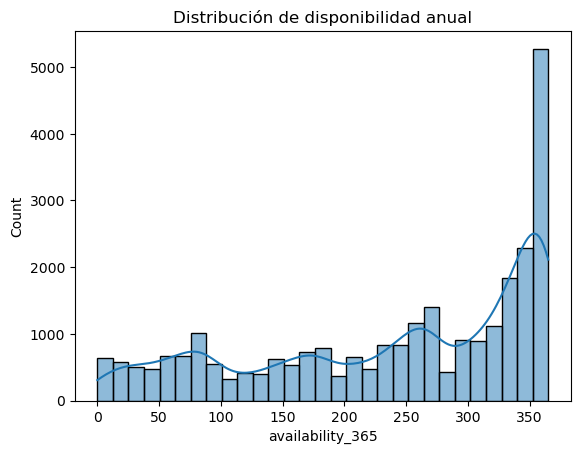

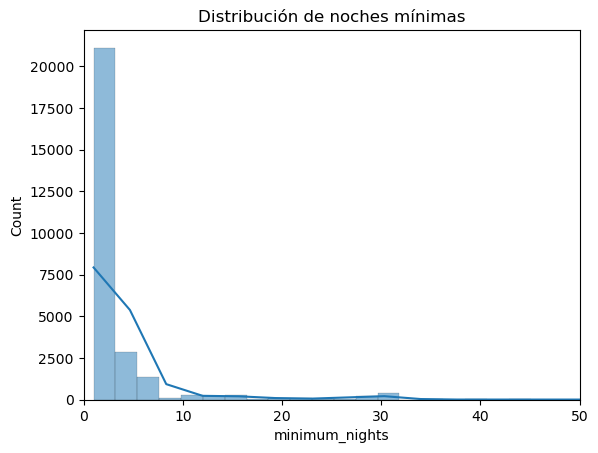

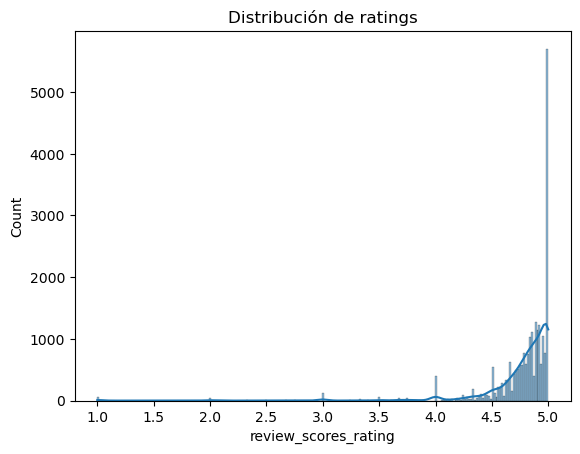

In [6]:
# Celda 6 Histogramas + KDE

sns.histplot(tp_data['availability_365'], kde=True)
plt.title('Distribución de disponibilidad anual')
plt.show()

#En este histograma limitamos el eje X esta el valor 50 debido a que hay un valor de 730 que complica la visualizacion
sns.histplot(tp_data['minimum_nights'], kde=True)
plt.xlim(0, 50)
plt.title('Distribución de noches mínimas')
plt.show()


sns.histplot(tp_data['review_scores_rating'].dropna(),kde=True)
plt.title('Distribución de ratings')
plt.show()

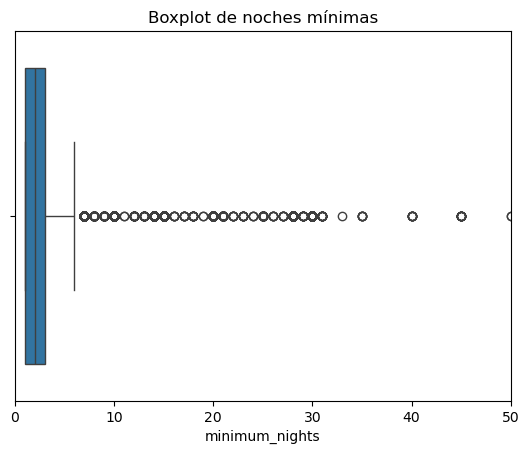

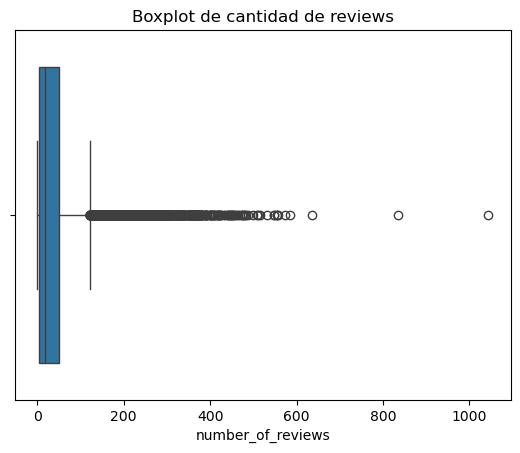

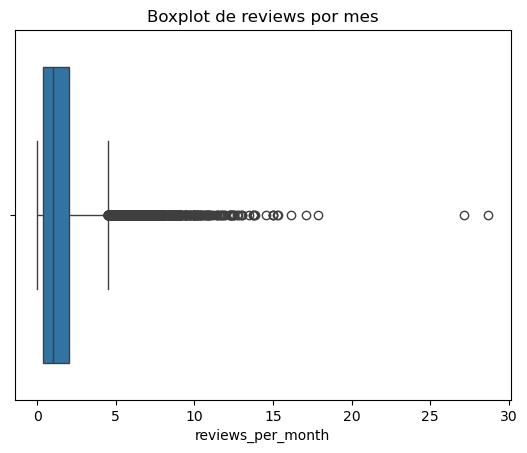

In [7]:
# Celda 7 Boxplots

#En este Boxplot limitamos el eje X esta el valor 50 debido a que hay un valor de 730 que complica la visualizacion
sns.boxplot(x=tp_data['minimum_nights'])
plt.xlim(0, 50)
plt.title('Boxplot de noches mínimas')
plt.show()

sns.boxplot(x=tp_data['number_of_reviews'])
plt.title('Boxplot de cantidad de reviews')
plt.show()

sns.boxplot(x=tp_data['reviews_per_month'].dropna())
plt.title('Boxplot de reviews por mes')
plt.show()

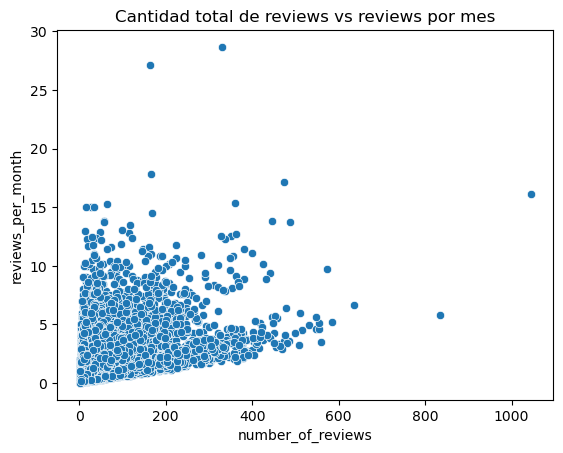

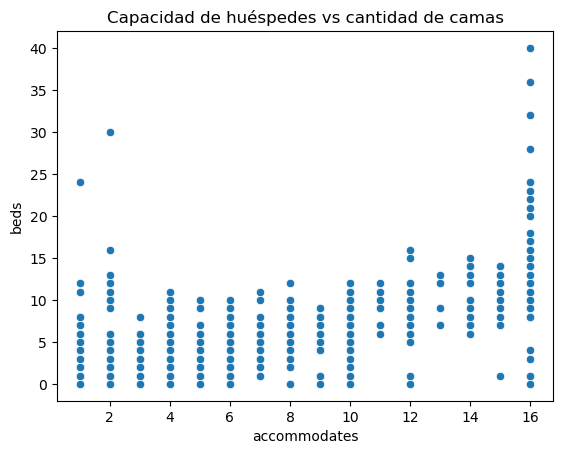

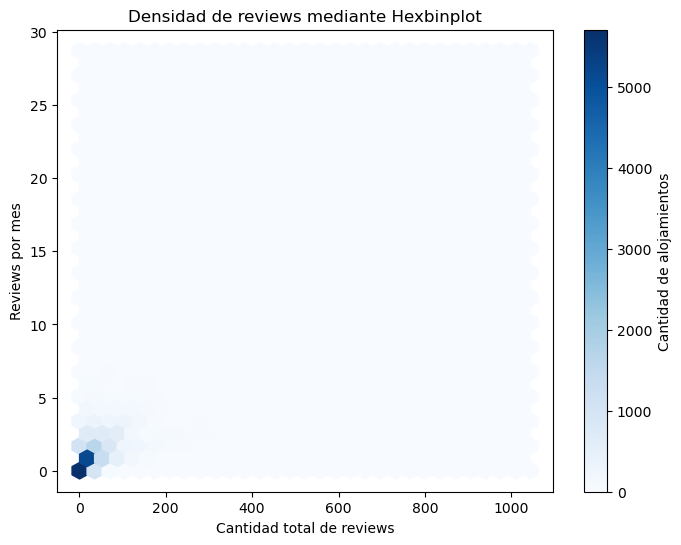

In [8]:
# Celda 8 Scatterplots

sns.scatterplot(
    data=tp_data,
    x='number_of_reviews',
    y='reviews_per_month'
)

plt.title('Cantidad total de reviews vs reviews por mes')
plt.show()



sns.scatterplot(
    data=tp_data,
    x='accommodates',
    y='beds'
)

plt.title('Capacidad de huéspedes vs cantidad de camas')
plt.show()




plt.figure(figsize=(8,6))
plt.hexbin(
    tp_data['number_of_reviews'],
    tp_data['reviews_per_month'],
    gridsize=30,
    cmap='Blues'
)

plt.colorbar(label='Cantidad de alojamientos')
plt.xlabel('Cantidad total de reviews')
plt.ylabel('Reviews por mes')
plt.title('Densidad de reviews mediante Hexbinplot')
plt.show()


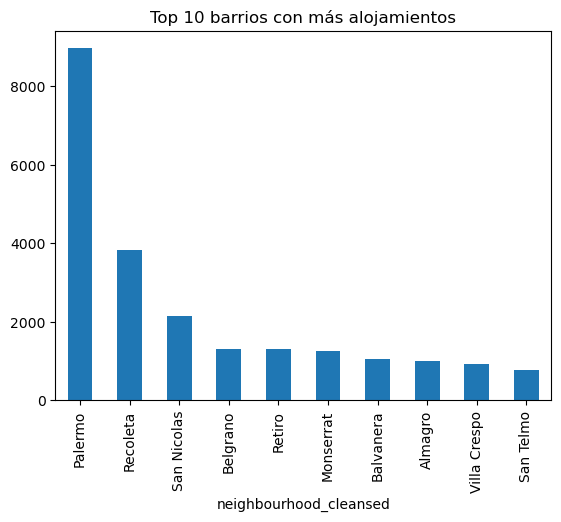

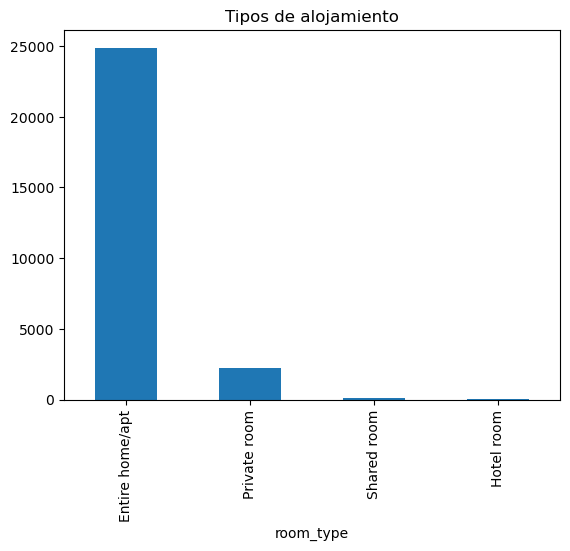

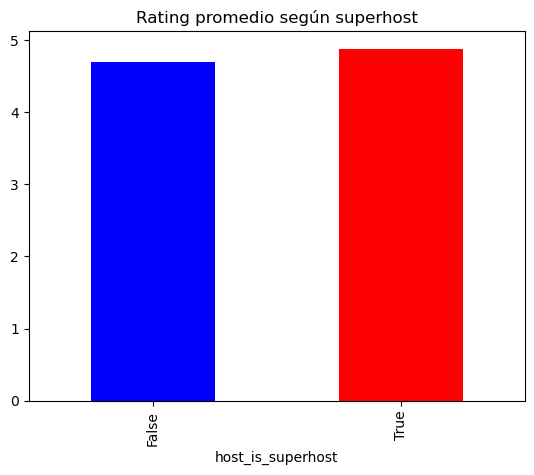

In [10]:
# celda 9 Visualizaciones adicionales

tp_data['neighbourhood_cleansed'] \
    .value_counts() \
    .head(10) \
    .plot(kind='bar')

plt.title('Top 10 barrios con más alojamientos')
plt.show()


tp_data['room_type'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Tipos de alojamiento')
plt.show()


tp_data.groupby(
    'host_is_superhost'
)['review_scores_rating'] \
.mean() \
.plot(kind='bar', color=['blue', 'red'])

plt.title('Rating promedio según superhost')
plt.show()


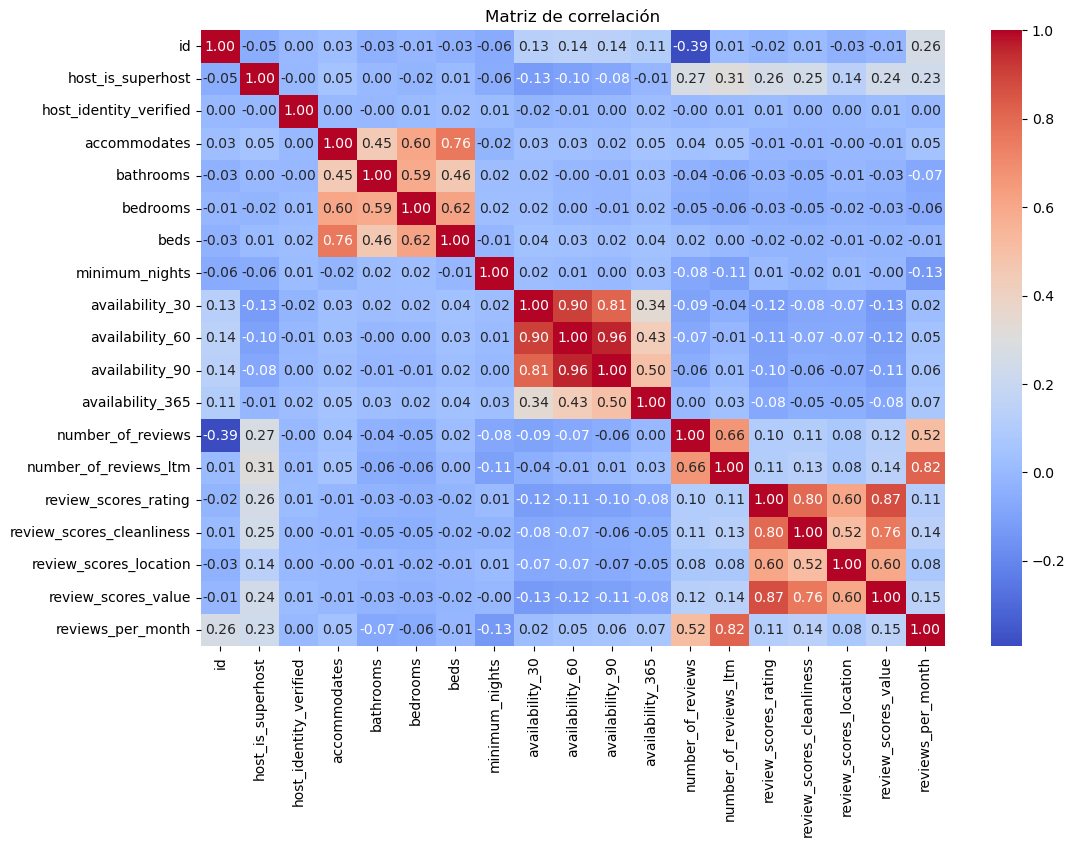

In [11]:
# Celda 10 Matriz de correlaciones
# Con esta matriz vemos de forma gráfica qué tan relacionadas están las variables numéricas

correlation_matrix = tp_data.corr(
    numeric_only=True
)



plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación')
plt.show()